In [42]:
from pathlib import Path
from PIL import Image
from glob import glob
import matplotlib.pyplot as plt
import torchvision
import math

In [43]:
DATA_DIR = '../data/UAVid/test_label/'
seq = 'seq26'
img_id = '000800.png'

orig_im = Image.open(Path(f'{DATA_DIR}/{seq}/Images/{img_id}'))
gt = Image.open(Path(f'{DATA_DIR}/{seq}/Labels/{img_id}'))

PRED_DIR = '../results/'
preds = glob(f'{PRED_DIR}/*/predictions/{seq}_{img_id}')
preds

['../results/unet_imagenet/predictions/seq26_000800.png',
 '../results/unetpp_ssl/predictions/seq26_000800.png',
 '../results/unetpp_imagenet/predictions/seq26_000800.png',
 '../results/deeplabv3_imagenet/predictions/seq26_000800.png',
 '../results/unet_ssl/predictions/seq26_000800.png',
 '../results/unet_random/predictions/seq26_000800.png',
 '../results/deeplabv3_ssl/predictions/seq26_000800.png']

In [44]:
MODEL_NAME_MAP = {
    'deeplabv3_imagenet': 'DeepLabV3 ImageNet',
    'deeplabv3_ssl': 'DeepLabV3 SSL',
    'unetpp_imagenet': 'Unet++ ImageNet',
    'unetpp_ssl': 'Unet++ SSL',
    'unet_imagenet': 'Unet ImageNet',
    'unet_ssl': 'Unet SSL',
    'unet_random': 'Unet RandomInit',
}
ORDER = [
    'deeplabv3_imagenet',
    'deeplabv3_ssl',
    'unetpp_imagenet',
    'unetpp_ssl',
    'unet_imagenet',
    'unet_ssl',
    'unet_random',
]

def sort_key(pred_path: str):
    model_dir = Path(pred_path).parent.parent.name  
    if model_dir in ORDER:
        return ORDER.index(model_dir)
    return len(ORDER), model_dir

In [45]:
def visualize_predictions(orig_im, gt, pred_paths):
    pred_paths = sorted(pred_paths, key=sort_key)
    num_preds = len(pred_paths)

    preds_per_row = 2
    rows_preds = math.ceil(num_preds / preds_per_row)

    total_rows = 1 + rows_preds   
    total_cols = 2

    fig, axes = plt.subplots(total_rows, total_cols,
                             figsize=(12, 6 + 3 * rows_preds))

    # top row: original + GT
    axes[0, 0].imshow(orig_im)
    axes[0, 0].set_title("Original Image")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(gt)
    axes[0, 1].set_title("Ground Truth")
    axes[0, 1].axis("off")

    # prediction rows
    idx = 0
    for r in range(1, total_rows):
        for c in range(total_cols):
            ax = axes[r, c]
            if idx < num_preds:
                pred_path = pred_paths[idx]
                model_dir = Path(pred_path).parent.parent.name
                display_name = MODEL_NAME_MAP.get(model_dir, model_dir)

                pred = Image.open(pred_path).transpose(Image.FLIP_LEFT_RIGHT)
                ax.imshow(pred)
                ax.set_title(display_name)
                ax.axis("off")
            else:
                ax.axis("off")
            idx += 1

    plt.tight_layout()
    plt.show()

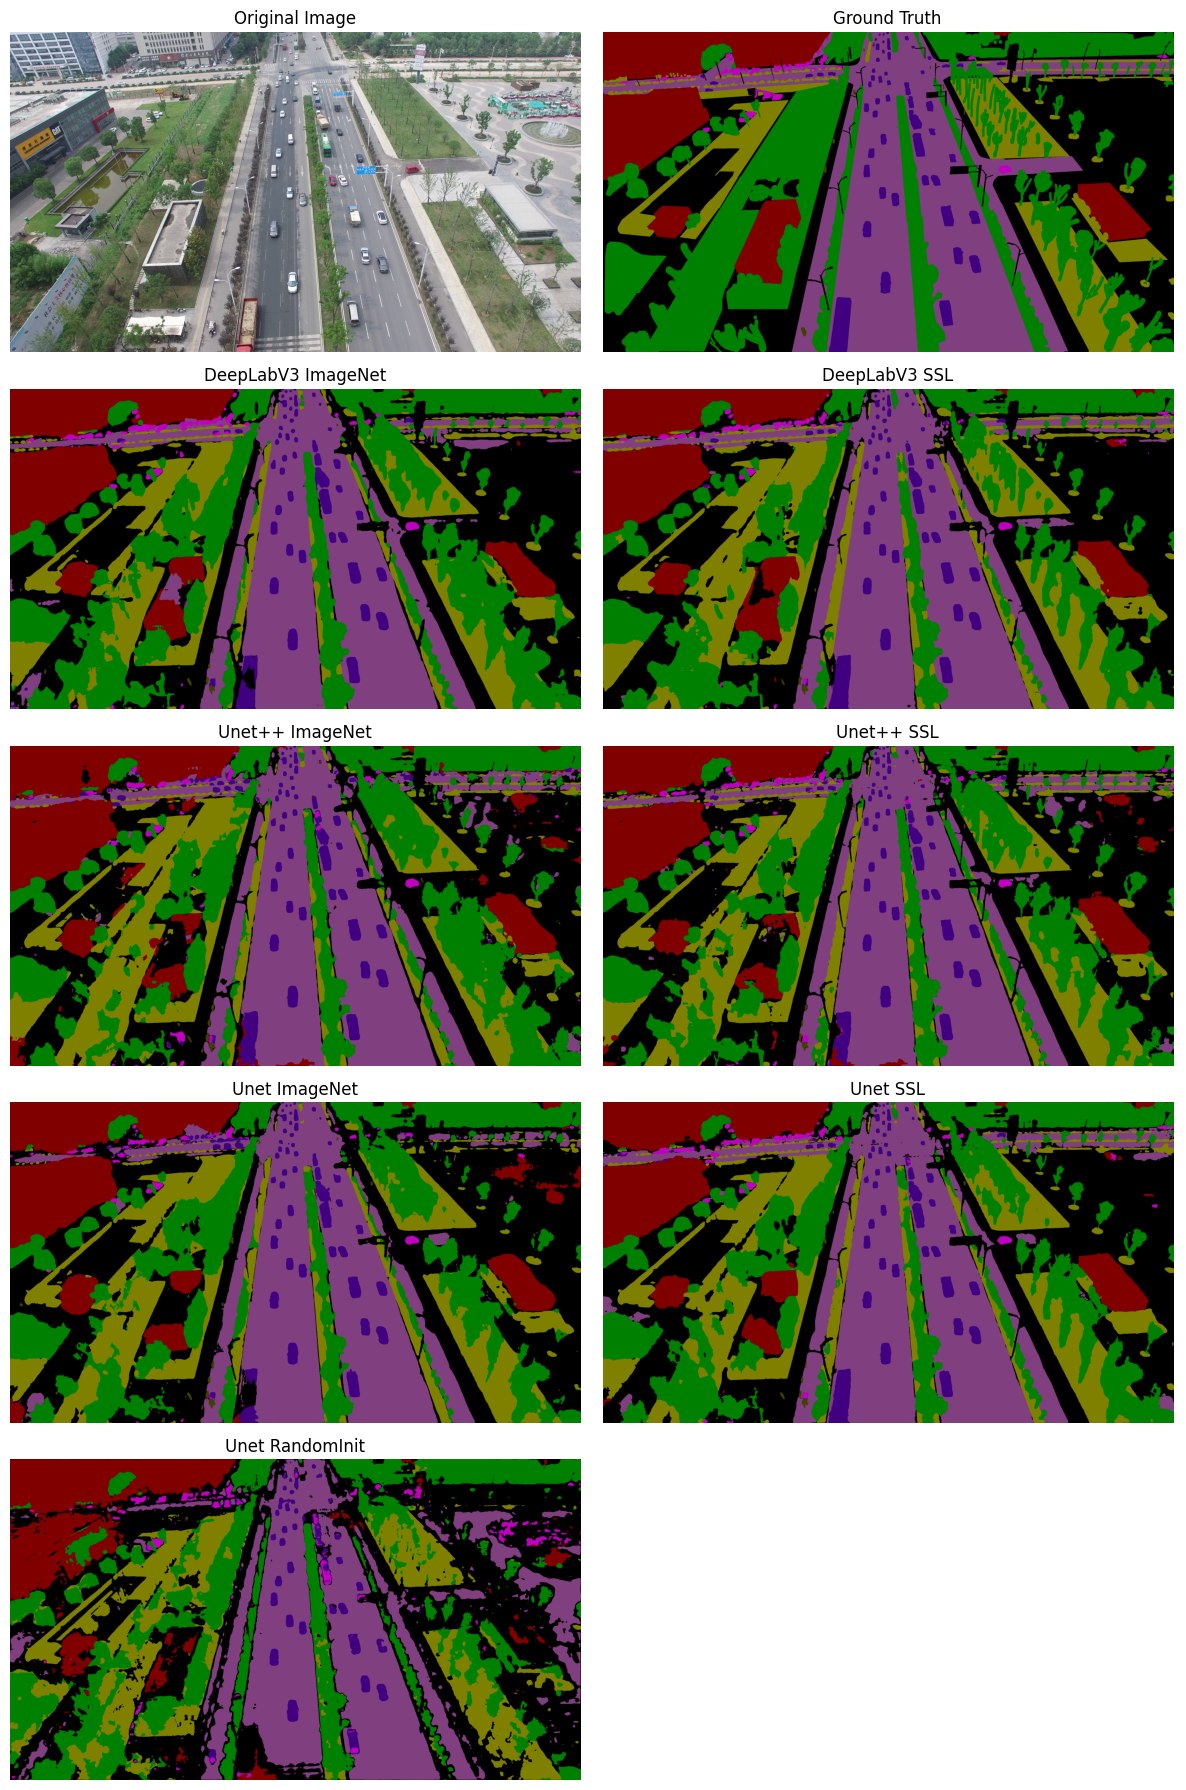

In [46]:
visualize_predictions(orig_im, gt, preds)

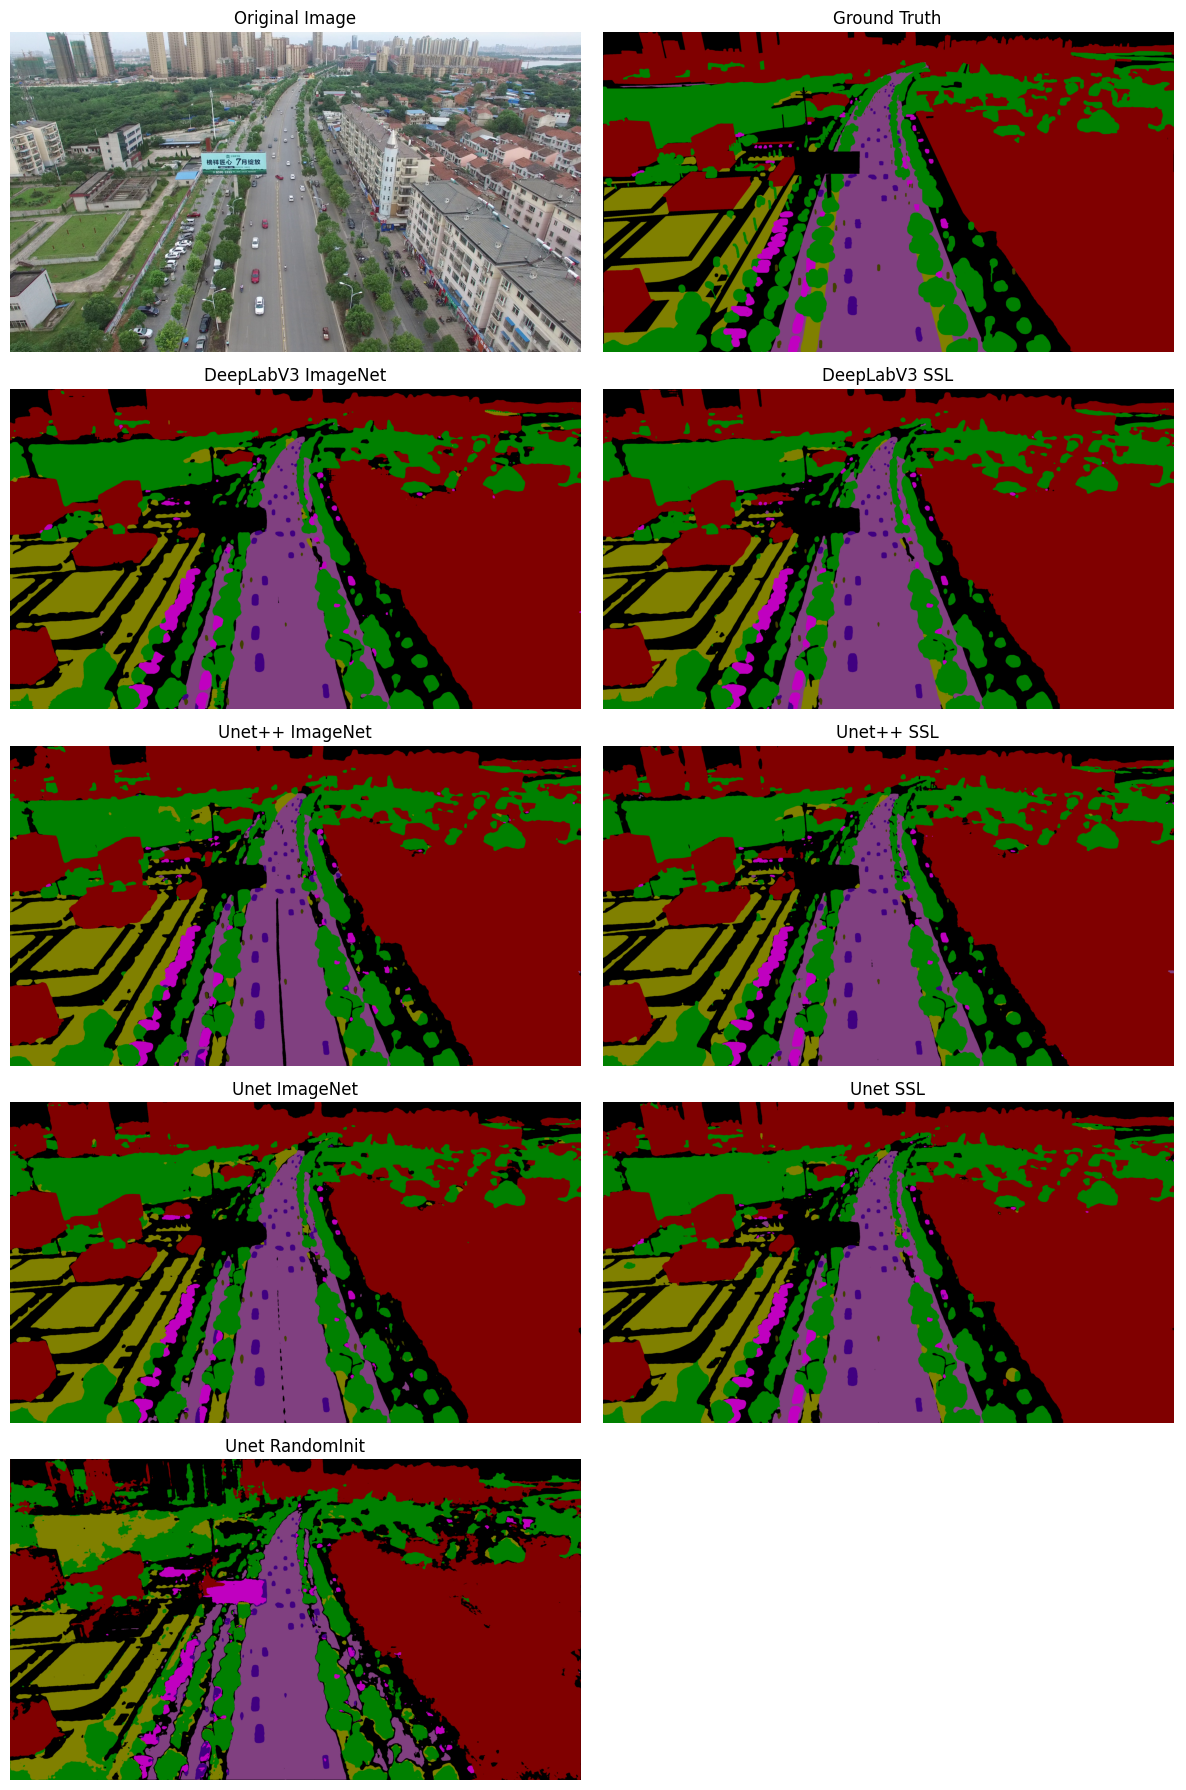

In [47]:
seq = 'seq21'
img_id = '000100.png'

orig_im = Image.open(Path(f'{DATA_DIR}/{seq}/Images/{img_id}'))
gt = Image.open(Path(f'{DATA_DIR}/{seq}/Labels/{img_id}'))

preds = glob(f'{PRED_DIR}/*/predictions/{seq}_{img_id}')
visualize_predictions(orig_im, gt, preds)